# From a STEP file to a vibroacoustic model — flush-mounted panel in a duct

A CAD file lands on the desk: `Library/WIP/Tubo_1m_1m.stp`. Nothing in it says what is
fluid, what is structure, or even what unit it is drawn in. This notebook takes it
all the way to a coupled analysis:

**STEP → dimensions and units → structured mesh with a flush panel → validation →
coupled modes → frequency response → reduced model.**

The physical question: a 3 m duct with a **1 m panel let into the middle of the
floor**, flush with the hard wall around it and clamped on its four edges
(C-C-C-C). Below the first cross-section resonance the duct carries plane waves,
so this is the classic problem of a flexible patch talking to a one-dimensional
sound field — it radiates into the duct when shaken, and it is driven by the duct
when a source is switched on at one end.

## Why the mesh has to be built this way

pyCAFE assembles CHEXA8 fluid elements and CQUAD4F shells, and the coupling
matrix is a surface integral over faces shared by both meshes. Two consequences
decide the whole meshing strategy:

* a **tetrahedral** mesh — what a CAD import gives by default — has no acoustic
  kernel here, so the geometry must be cut into boxes and meshed transfinitely;
* the panel must be a **patch of the wall**, not a separate surface laid on top,
  otherwise its nodes are not the fluid nodes and there is nothing to couple.

Both are handled by `duct_with_flush_plate`, which cuts the duct at the two ends
of the panel and meshes the three pieces as structured boxes.

In [1]:
import os
import sys
import time

sys.path.insert(0, os.path.abspath(os.path.join("..", "..")))          # run from examples/

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh

import pycafe
from pycafe.boundary_condition import AcousticBC
from pycafe.boundary_condition.acoustic_bc import build_impedance_operator
from pycafe.core.model_spec import AIR, Library, ModelSpec, aluminium, build_model
from pycafe.create_geom import (
    ask_for_file, describe_conventions, inspect_cad, list_groups,
)
from pycafe.post_processing.post_processing_3d import plot_pressure_3d
from pycafe.solver.solver_modale import solve_modal_acoustic_reduced
from pycafe.solver.solver_vibroacoustic import (
    build_coupled_blocks,
    expand_pressure,
    solve_vibroacoustic_frequency_sweep,
    solve_vibroacoustic_modal,
    structural_displacement_field,
)
from pycafe.solver.solver_vibroacoustic_modal import (
    build_coupled_modal_basis,
    solve_coupled_modal_frequency_sweep,
)

# Where is the geometry? The dialog opens on Library/, where the CAD files
# sit next to the meshes; with no display the question is asked on the
# console. No answer, no run -- there is no fallback file (a batch run
# answers with PYCAFE_FILE_CAD=<path>). Here: Library/WIP/Tubo_1m_1m.stp.
STEP = ask_for_file("cad", title="pyCAFE — select the duct geometry")

# ------------------------------ model data ------------------------------
PLATE_LENGTH = 1.0                      # panel extent along the duct [m]
F_MIN, F_MAX, DF = 10.0, 200.0, 0.5     # sweep [Hz]
ETA_S = 0.02                            # structural loss factor
ZETA_WALL = 200.0                       # lightly lined walls (alpha ~ 2%)

# The whole input in one object: where the geometry comes from (a CAD file,
# meshed by the duct builder), what the two media are, and the highest
# frequency the mesh has to resolve. 13 elements per wavelength instead of
# the default 10 buys the 1% dispersion error this notebook quotes.
spec = ModelSpec(
    geometry=Library("duct_with_flush_plate", cad_path=STEP,
                     plate_length=PLATE_LENGTH,
                     plate_face="z_min"),          # the floor of the duct
    fluid=AIR,
    structure=aluminium(t=2.0e-3, support="clamped"),   # C-C-C-C
    f_max=F_MAX,
    elements_per_wavelength=13,
    output_path="tubo_flush_plate.msh",
)
print(spec.describe())

RHO0, C0 = spec.fluid.rho0, spec.fluid.c0
T, RHO_S, E, NU = (spec.structure.t, spec.structure.rho_s,
                   spec.structure.E, spec.structure.nu)

ModelSpec
  geometry     Library('duct_with_flush_plate', cad_path='/Users/danielefabbri/Desktop/pycafe_new/Geom/Tubo_1m_1m.stp', plate_length=1.0, plate_face='z_min')
  fluid        air: rho0 = 1.204 kg/m3, c0 = 343.0 m/s
  structure    aluminium: t = 2.00 mm, E = 70 GPa, nu = 0.33, rho = 2700.0 kg/m3, clamped
  f_max        200.0 Hz (lambda = 1715 mm)
  mesh size    131.9 mm (13 elements per wavelength)
  mesh file    tubo_flush_plate.msh
  bending      lambda_b = 313 mm at f_max  (shorter than the acoustic one: check the panel mesh)


## 1. What is in the STEP file?

Before meshing anything, ask the file. `inspect_cad` imports it, brings it to
metres — anything larger than 100 units is read as millimetres, which is what most
CAD exports are — and lists every solid and face with its tag, its size and its
bounding box.

That listing is what makes the roles assignable: a STEP file says nothing about
fluid or structure, so somebody has to point at a tag and say what it is. Here the
geometry is a plain box and the duct builder does the pointing itself; for a
general CAD file the tags below go straight into
`CadFile(path, fluid=[...], structure=[...])`.

In [2]:
entities = inspect_cad(STEP)

solid = entities[3][0]
extent = solid.bbox_max - solid.bbox_min
print()
print(f"volume {solid.size:.4g} m3 against {np.prod(extent):.4g} m3 for its "
      f"bounding box -> ratio {solid.size / np.prod(extent):.4f}")
print("A ratio of 1 means the solid *is* its bounding box: a duct, meshable")
print("with hexahedra. A ratio below 1 would need cutting into boxes first,")
print("since a tetrahedral mesh has no acoustic kernel here.")

/Users/danielefabbri/Desktop/pycafe_new/Geom/Tubo_1m_1m.stp  (scaled by 0.001 to metres)
  dim 3  tag    1   volume 3.000e+00   bbox 3.000 x 1.000 x 1.000   centre (1.500, 0.500, -0.500)
  dim 2  tag    2   area   3.000e+00   bbox 3.000 x 0.000 x 1.000   centre (1.500, 0.000, -0.500)
  dim 2  tag    3   area   3.000e+00   bbox 3.000 x 1.000 x 0.000   centre (1.500, 0.500, 0.000)
  dim 2  tag    4   area   3.000e+00   bbox 3.000 x 0.000 x 1.000   centre (1.500, 1.000, -0.500)
  dim 2  tag    5   area   3.000e+00   bbox 3.000 x 1.000 x 0.000   centre (1.500, 0.500, -1.000)
  dim 2  tag    1   area   1.000e+00   bbox 0.000 x 1.000 x 1.000   centre (3.000, 0.500, -0.500)
  dim 2  tag    6   area   1.000e+00   bbox 0.000 x 1.000 x 1.000   centre (0.000, 0.500, -0.500)

Name them with by_tag(dim, tags, 'fluid') / CadFile(..., fluid=[...], structure=[...]).

volume 3 m3 against 3 m3 for its bounding box -> ratio 1.0000
A ratio of 1 means the solid *is* its bounding box: a duct, meshable
with 

## 2. Mesh it and assemble it

`build_model` reads the spec: it meshes the duct with the panel let into the
floor, validates the mesh at `f_max`, **draws it** — the duct transparent, the
panel red on the floor, the two ends in their own colours — and only then
assembles both domains with the coupling matrix. The panel is placed by length and position; the element size is not an
input, it follows from `f_max` and the element density.

The rule behind the size: the trilinear acoustic element has a dispersion error of
about $164/n_\lambda^2$ percent, so 13 elements per wavelength buy 1%, 10 (the
default) about 1.6%, and 6 are the practical floor — below that the spec is
refused.

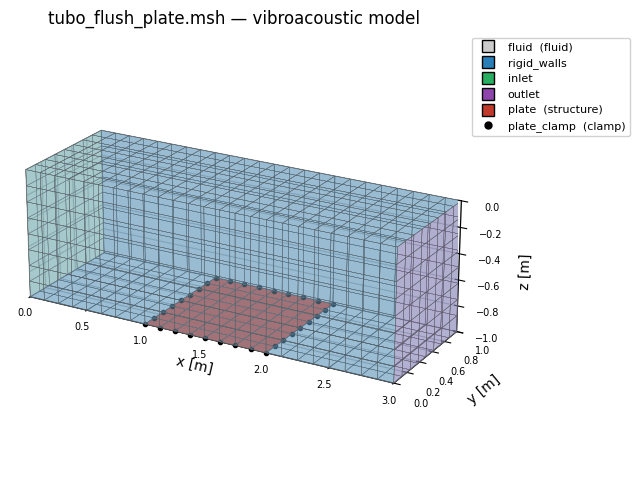

tubo_flush_plate.msh  (vibroacoustic analysis)
----------------------------------------------
  2025 nodes, 32 x Line 2, 896 x Quadrilateral 4, 1536 x Hexahedron 8
  roles: fluid = 'fluid', structure = 'plate', clamp = 'plate_clamp'
  · interface conforming: 64 faces, one fluid element behind each
  · fluid element size: 125.0 / 125.0 / 125.0 mm (min / mean / max)
  · good to ~1% up to 211 Hz (13 elements per wavelength at c0 = 343 m/s)
  · at 200 Hz: 13.7 elements per wavelength, dispersion error ~0.87%
  · selectable boundaries: inlet, outlet, rigid_walls
  => usable


In [3]:
model = build_model(spec)

nodes = model["nodes"]
elements = model["elements"]
boundaries = model["boundaries"]
groups = model["groups"]
system = model["system"]
mesh_path = model["mesh_path"]

print(model["report"])

The groups it wrote are the ones the solvers look up by name. `fluid` and `plate`
are roles; `rigid_walls` is a free name, there only so a boundary condition can be
attached to it later.

In [4]:
list_groups(str(mesh_path))
print()
print(describe_conventions())

tubo_flush_plate.msh:
  dim 1  plate_clamp          32 nodes (role clamp)
  dim 2  plate                81 nodes (role structure)
  dim 2  rigid_walls         751 nodes (boundary name)
  dim 2  inlet                81 nodes (boundary name)
  dim 2  outlet               81 nodes (boundary name)
  dim 3  fluid              2025 nodes (role fluid)

Physical groups pyCAFE looks for by name:

  fluid        the acoustic domain: CHEXA8 in 3D, CQUAD4/8 in 2D
               also accepted: acoustic, domain

  plate        the structural domain (CQUAD4F shells); on a coupled mesh its elements are also the interface faces
               also accepted: structure, shell

  pml          the absorbing layer wrapped around the fluid; naming it is the whole switch — no group, no PML. Same element types as the fluid, and conforming with it
               also accepted: absorbing_layer

  plate_clamp  nodes where the structure is supported (clamped or pinned, chosen by the 'support' argument, not by the 

In [5]:
plate_conn = groups["plate"]["elements"]["Quadrilateral 4"] - 1

print(f"panel: {plate_conn.shape[0]} CQUAD4 over "
      f"{np.ptp(nodes[np.unique(plate_conn), 0]):.2f} x "
      f"{np.ptp(nodes[np.unique(plate_conn), 1]):.2f} m at z = "
      f"{nodes[plate_conn[0, 0], 2]:.2f} m, "
      f"{np.unique(plate_conn).size} nodes shared with the fluid")

panel: 64 CQUAD4 over 1.00 x 1.00 m at z = -1.00 m, 81 nodes shared with the fluid


## 3. The coupled system

The spec carried `support="clamped"` on the panel material, and that is what turns
the `plate_clamp` group into C-C-C-C: all six DOF held on the border of the panel,
which is what "flush-mounted in a hard wall" means mechanically. The mesh only
says *which* nodes are held.

The check to run every time: a uniform unit pressure on the interface must
integrate to the panel area, along the panel normal.

In [6]:
n_s = system["structural"]["idx_free"].size
n_a = system["acoustic"]["nodes0"].size
print(f"fluid      : {system['domains']['fluid']['conn0'].shape[0]} CHEXA8, "
      f"{n_a} pressure DOF")
print(f"structure  : {system['domains']['structure']['conn0'].shape[0]} CQUAD4F, "
      f"{n_s} free DOF after the clamp ({system['structural']['support']})")
print(f"interface  : {system['interface']['conn0'].shape[0]} faces, "
      f"mean normal {np.round(system['interface']['normals'].mean(axis=0), 9)}")
print(f"vector area: {np.round(system['coupling']['area_vector'], 6)} m2 "
      f"(panel area {PLATE_LENGTH * np.ptp(nodes[np.unique(plate_conn), 1]):.3f} m2, "
      "normal -z: the fluid is above the floor)")

fluid      : 1536 CHEXA8, 2025 pressure DOF
structure  : 64 CQUAD4F, 294 free DOF after the clamp (clamped)
interface  : 64 faces, mean normal [-0.  0. -1.]
vector area: [-0. -0. -1.] m2 (panel area 1.000 m2, normal -z: the fluid is above the floor)


## 4. What to expect: the two uncoupled problems

* **Duct, rigid everywhere.** Both ends closed, so the axial modes are
  $f_n = n\,c_0/(2L)$ — 57, 114, 171 Hz for $L = 3$ m — and the first
  cross-section mode is at $c_0/(2 \times 1\ \mathrm{m}) = 171$ Hz. Below that the
  duct is one-dimensional.
* **Panel in vacuo.** A 1 m x 1 m aluminium plate, 2 mm, clamped all round.
  Warburton's beam-function formula gives the reference. Note that the panel mesh
  is not free: it is whatever the fluid mesh leaves on the wall, 8 x 8 elements
  here, so its higher modes are the coarser part of the model — a few percent
  high, which is what the comparison shows.

The two families overlap in this band, which is exactly when coupling is
interesting: a panel mode and a duct mode at nearby frequencies exchange energy.

In [7]:
K_s = system["structural"]["K_red"].tocsc()
M_s = system["structural"]["M_red"].tocsc()
vals, _ = eigsh(K_s, k=16, M=M_s, sigma=0.0, which="LM")
f_plate = np.sqrt(np.abs(np.sort(vals))) / (2 * np.pi)

D = E * T ** 3 / (12.0 * (1.0 - NU ** 2))


def warburton_cccc(m, n, a, b, D, mass, nu):
    """Warburton (1954) frequency of a CCCC plate, mode (m, n)."""
    def GHJ(k):
        if k == 1:
            return 1.506, 1.248, 1.248
        G = k + 0.5
        H = J = G ** 2 * (1.0 - 2.0 / (G * np.pi))
        return G, H, J

    Gx, Hx, Jx = GHJ(m)
    Gy, Hy, Jy = GHJ(n)
    term = (Gx ** 4 / a ** 4 + Gy ** 4 / b ** 4
            + 2.0 / (a ** 2 * b ** 2) * (nu * Hx * Hy + (1.0 - nu) * Jx * Jy))
    return np.pi ** 2 * np.sqrt(D / mass) * np.sqrt(term) / (2.0 * np.pi)


a_plate = PLATE_LENGTH
b_plate = float(np.ptp(nodes[np.unique(plate_conn), 1]))
ref = sorted((warburton_cccc(m, n, a_plate, b_plate, D, RHO_S * T, NU), (m, n))
             for m in range(1, 4) for n in range(1, 4))[:4]

print("panel in vacuo (CCCC)")
print("  (m,n)    pyCAFE [Hz]   Warburton [Hz]   diff")
for i, (f_ref, mn) in enumerate(ref):
    print(f"  {str(mn):<7} {f_plate[i]:10.2f}   {f_ref:12.2f}   "
          f"{(f_plate[i] / f_ref - 1) * 100:+6.2f} %")

f_duct, _ = solve_modal_acoustic_reduced(
    system["acoustic"]["K"], system["acoustic"]["M"], num_modes=6
)
L_duct = float(np.ptp(nodes[:, 0]))
W_duct = float(np.ptp(nodes[:, 1]))
H_duct = float(np.ptp(nodes[:, 2]))
exact_duct = sorted(
    (C0 / 2 * np.sqrt((l / L_duct) ** 2 + (m / W_duct) ** 2 + (n / H_duct) ** 2),
     (l, m, n))
    for l in range(6) for m in range(2) for n in range(2)
)[1:7]

print("\nrigid duct (both ends closed)")
print("  (l,m,n)     pyCAFE [Hz]   exact [Hz]   error")
for i, (f_ex, lmn) in enumerate(exact_duct):
    print(f"  {str(lmn):<10} {f_duct[i]:10.2f}   {f_ex:9.2f}   "
          f"{(f_duct[i] / f_ex - 1) * 100:+6.3f} %")
print("\nThe modes with l only are the axial ones, c0/(2L) apart; (0,0,1) and")
print("(0,1,0) at 171.5 Hz are the first cross-section modes — above them the")
print("duct stops being one-dimensional.")

panel in vacuo (CCCC)
  (m,n)    pyCAFE [Hz]   Warburton [Hz]   diff
  (1, 1)       18.03          17.91    +0.70 %
  (1, 2)       38.53          36.55    +5.40 %
  (2, 1)       38.53          36.55    +5.40 %
  (2, 2)       57.69          53.93    +6.97 %

rigid duct (both ends closed)
  (l,m,n)     pyCAFE [Hz]   exact [Hz]   error
  (1, 0, 0)       57.21       57.17   +0.071 %
  (2, 0, 0)      114.66      114.33   +0.286 %
  (0, 0, 1)      172.60      171.50   +0.644 %
  (0, 1, 0)      172.60      171.50   +0.644 %
  (3, 0, 0)      172.60      171.50   +0.644 %
  (1, 0, 1)      181.84      180.78   +0.587 %

The modes with l only are the axial ones, c0/(2L) apart; (0,0,1) and
(0,1,0) at 171.5 Hz are the first cross-section modes — above them the
duct stops being one-dimensional.


## 5. Coupled modes

The air load moves both families. The energy split
$E_s/(E_s+E_a)$ — structural kinetic against acoustic potential — says which is
which, and the interesting ones are those in between: neither a panel mode nor a
duct mode, but a genuine exchange.

In [8]:
blocks_free = build_coupled_blocks(system)
f_coupled, modes = solve_vibroacoustic_modal(system, num_modes=22,
                                             blocks=blocks_free)

Ms_b, Ma_b = blocks_free["Ms"], blocks_free["Ma"]
ns = blocks_free["n_s"]
frac = np.zeros(f_coupled.size)

# Compare each coupled mode with its own family: a panel-like mode against
# the panel in vacuo, a duct-like one against the rigid duct.
families = {"panel": (f_plate, [f"panel {i + 1}" for i in range(f_plate.size)]),
            "duct": (f_duct, [f"duct {lmn}" for _, lmn in exact_duct])}

print("   f [Hz]   Es/(Es+Ea)   character      nearest uncoupled     shift")
for i, f in enumerate(f_coupled):
    w, p = modes[:ns, i], modes[ns:, i]
    Es = (2 * np.pi * f) ** 2 * (w @ (Ms_b @ w))
    Ea = (p @ (Ma_b @ p)) / RHO0
    frac[i] = Es / (Es + Ea) if (Es + Ea) > 0 else 0.0
    if f < 1.0:
        print(f"{f:9.2f}   {frac[i]:9.3f}   uniform pressure of the sealed duct")
        continue
    kind = ("panel-like " if frac[i] > 0.75 else
            "duct-like  " if frac[i] < 0.25 else "coupled    ")
    ref_f, ref_labels = families["panel" if frac[i] > 0.5 else "duct"]
    j = int(np.argmin(np.abs(ref_f - f)))
    print(f"{f:9.2f}   {frac[i]:9.3f}   {kind}    {ref_labels[j]:<16} "
          f"{(f / ref_f[j] - 1) * 100:+7.2f} %")

   f [Hz]   Es/(Es+Ea)   character      nearest uncoupled     shift
     0.00       0.000   uniform pressure of the sealed duct
    20.29       0.785   panel-like     panel 1           +12.49 %
    37.70       0.994   panel-like     panel 2            -2.13 %
    37.76       0.999   panel-like     panel 2            -1.98 %
    56.91       1.000   panel-like     panel 4            -1.35 %
    57.39       0.012   duct-like      duct (1, 0, 0)     +0.32 %
    74.25       0.994   panel-like     panel 5            -1.28 %
    74.48       0.991   panel-like     panel 5            -0.98 %
    93.99       0.998   panel-like     panel 7            -1.05 %
    94.01       0.999   panel-like     panel 7            -1.02 %
   115.80       0.026   duct-like      duct (2, 0, 0)     +0.99 %
   129.54       0.996   panel-like     panel 9            -0.78 %
   132.33       0.993   panel-like     panel 10           -1.24 %
   132.64       0.994   panel-like     panel 10           -1.01 %
   159.32     

## 6. Frequency response, both ways round

Two load cases on the same model, which is the point of a coupled formulation:

1. **1 N on the panel** — how much sound a shaken panel puts into the duct;
2. **a monopole near one end** — how much the panel moves when the duct is driven.

Damping: a loss factor on the panel, and walls with a large but finite normalized
impedance so the duct resonances stay finite.

In [9]:
C_a = build_impedance_operator(
    AcousticBC().add_impedance("rigid_walls", ZETA_WALL),
    nodes=nodes, rho=RHO0, c0=C0, boundaries=boundaries, groups=groups,
    elements=elements, boundary_dim=2,
).at(0.0)

blocks = build_coupled_blocks(system, C_a=C_a, eta_s=ETA_S)

# Drive point: centre of the panel, transverse DOF.
idx_s = system["structural"]["idx_free"]
node_of_dof, component = idx_s // 6, idx_s % 6
panel_nodes = np.unique(node_of_dof)
centre = np.array([nodes[panel_nodes, 0].mean(), nodes[panel_nodes, 1].mean(),
                   nodes[panel_nodes, 2].mean()])
drive_node = panel_nodes[np.argmin(
    np.linalg.norm(nodes[panel_nodes] - centre, axis=1)
)]
dof = int(np.where((node_of_dof == drive_node) & (component == 2))[0][0])

F_s = np.zeros(blocks["n_s"])
F_s[dof] = 1.0

# Monopole: nearest fluid node to a point 0.25 m from the inlet, on the axis.
idx_a = blocks["idx_a"]
source_target = np.array([0.25, nodes[:, 1].mean(), nodes[:, 2].mean()])
source_node = idx_a[np.argmin(
    np.linalg.norm(nodes[idx_a] - source_target, axis=1)
)]
F_a = np.zeros(blocks["n_a"])
F_a[int(np.where(idx_a == source_node)[0][0])] = 1.0

# Microphone at the far end, on the axis.
mic_target = np.array([nodes[:, 0].max() - 0.1, nodes[:, 1].mean(),
                       nodes[:, 2].mean()])
mic_node = idx_a[np.argmin(np.linalg.norm(nodes[idx_a] - mic_target, axis=1))]
mic_row = int(np.where(idx_a == mic_node)[0][0])

print(f"drive at node {drive_node} {np.round(nodes[drive_node], 3)}")
print(f"source at node {source_node} {np.round(nodes[source_node], 3)}")
print(f"mic at node {mic_node} {np.round(nodes[mic_node], 3)}")

frequencies = np.arange(F_MIN, F_MAX + DF, DF)
t0 = time.time()
res_force = solve_vibroacoustic_frequency_sweep(
    system, frequencies, F_s=F_s, blocks=blocks, verbose=False,
)
res_source = solve_vibroacoustic_frequency_sweep(
    system, frequencies, F_a=F_a, blocks=blocks, verbose=False,
)
t_direct = time.time() - t0
print(f"\ntwo direct sweeps: {frequencies.size} frequencies x "
      f"{blocks['n_s'] + blocks['n_a']} unknowns in {t_direct:.1f} s")

drive at node 726 [ 1.5  0.5 -1. ]
source at node 1755 [ 0.25  0.5  -0.5 ]
mic at node 1164 [ 2.875  0.5   -0.5  ]



two direct sweeps: 381 frequencies x 2319 unknowns in 23.6 s


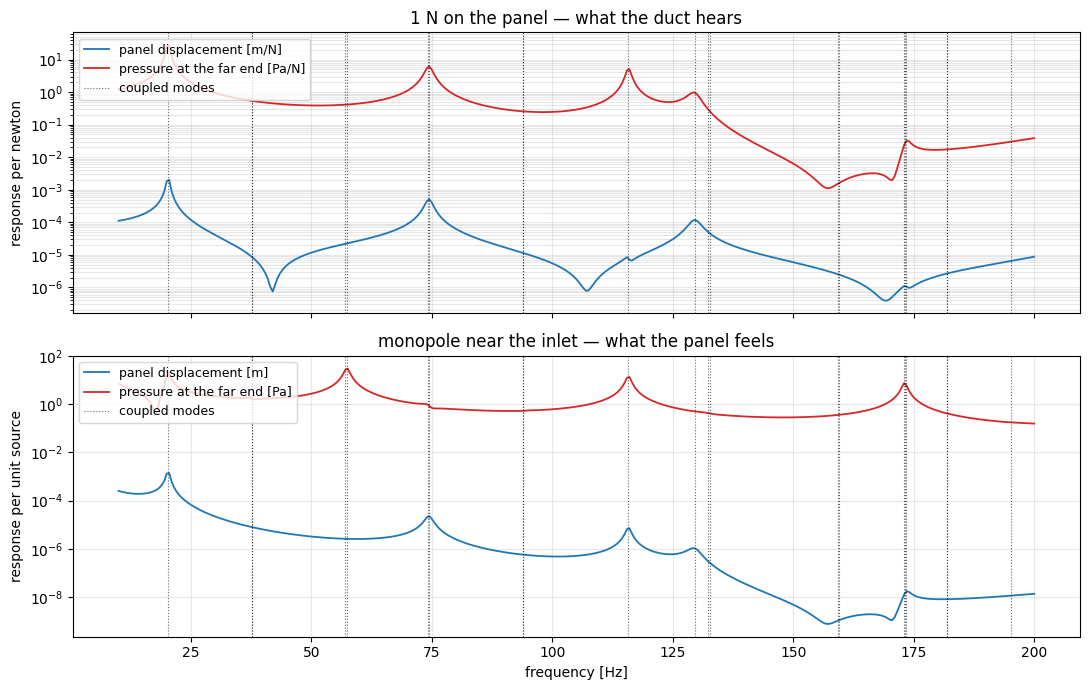

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7.0), sharex=True)

axes[0].semilogy(frequencies, np.abs(res_force["w"][dof]), color="C0", lw=1.3,
                 label="panel displacement [m/N]")
axes[0].semilogy(frequencies, np.abs(res_force["p"][mic_row]), color="C3",
                 lw=1.3, label="pressure at the far end [Pa/N]")
axes[0].set_title("1 N on the panel — what the duct hears")
axes[0].set_ylabel("response per newton")

axes[1].semilogy(frequencies, np.abs(res_source["w"][dof]), color="C0", lw=1.3,
                 label="panel displacement [m]")
axes[1].semilogy(frequencies, np.abs(res_source["p"][mic_row]), color="C3",
                 lw=1.3, label="pressure at the far end [Pa]")
axes[1].set_title("monopole near the inlet — what the panel feels")
axes[1].set(xlabel="frequency [Hz]", ylabel="response per unit source")

for ax in axes:
    for k, f in enumerate(f_coupled[(f_coupled > F_MIN) & (f_coupled < F_MAX)]):
        ax.axvline(f, color="k", ls=":", lw=0.8, alpha=0.6,
                   label="coupled modes" if k == 0 else None)
    ax.grid(alpha=0.3, which="both")
    ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

Every peak sits on a coupled natural frequency, and the two load cases light up
the same ones — the modes belong to the model, not to the excitation. What changes
is *how much* each one is excited: a force at the centre of the panel cannot drive
a mode with a node line there, and a monopole on the duct axis cannot drive a
cross-mode with a node on the axis.

In [11]:
def peaks_of(response, freqs):
    a = np.abs(response)
    return np.array([freqs[i] for i in range(1, freqs.size - 1)
                     if a[i] > a[i - 1] and a[i] >= a[i + 1]])


print(" peak [Hz]   from        nearest coupled mode   character")
for name, response in (("force  ", res_force["w"][dof]),
                       ("source ", res_source["p"][mic_row])):
    for f_pk in peaks_of(response, frequencies):
        j = int(np.argmin(np.abs(f_coupled - f_pk)))
        kind = ("panel-like" if frac[j] > 0.75 else
                "duct-like " if frac[j] < 0.25 else "coupled   ")
        print(f" {f_pk:9.1f}   {name}    {f_coupled[j]:14.2f}   {kind}")

 peak [Hz]   from        nearest coupled mode   character
      20.5   force               20.29   panel-like
      74.5   force               74.48   panel-like
     115.5   force              115.80   duct-like 
     129.5   force              129.54   panel-like
     173.0   force              173.08   duct-like 
      20.5   source              20.29   panel-like
      37.5   source              37.70   panel-like
      57.5   source              57.39   duct-like 
     116.0   source             115.80   duct-like 
     173.0   source             173.08   duct-like 


## 7. The pressure field at a coupled resonance

At a panel-like resonance the patch acts as a piston on a duct that is much longer
than it is wide: the field is the axial standing wave the panel manages to excite,
not a local bubble over the panel.

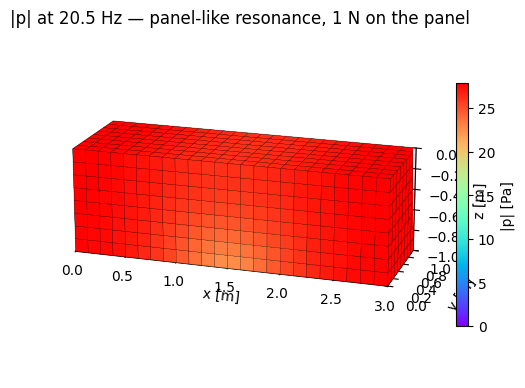

(<Figure size 1100x450 with 2 Axes>,
 <Axes3D: title={'center': '|p| at 20.5 Hz — panel-like resonance, 1 N on the panel'}, xlabel='x [m]', ylabel='y [m]', zlabel='z [m]'>)

In [12]:
i_panel = int(np.argmax((frac > 0.75) & (f_coupled > 1.0)))
k = int(np.argmin(np.abs(frequencies - f_coupled[i_panel])))
p_full = expand_pressure(res_force["p"], res_force["idx_a"], nodes.shape[0])

plot_pressure_3d(
    nodes, elements, p_full[:, k], part="abs", elev=18, azim=-72,
    figsize=(11, 4.5),
    title=f"|p| at {frequencies[k]:.1f} Hz — panel-like resonance, 1 N on the panel",
)

## 8. The same sweep on a reduced model

The direct sweep factorizes the coupled matrix once per frequency. On this model
that is a few seconds; on a finer one it is the whole cost of the study. The
coupled modes computed in section 5 are already a basis — expanding on them turns
each frequency into a small dense solve.

This is optional: the direct solver remains the reference, and the comparison
below is how one decides whether the reduced model is good enough for the band of
interest.

basis      : 70 coupled modes up to 421 Hz, built in 0.09 s
direct     : 381 solves of 2319 unknowns   11.82 s
modal      : 381 solves of   70 unknowns   0.03 s   (360x)
error      : w 2.0e-02   p 1.3e-02


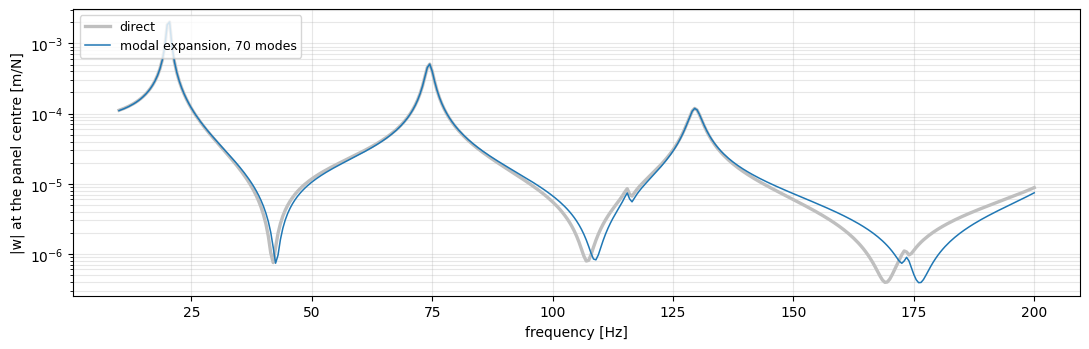

In [13]:
blocks_undamped = build_coupled_blocks(system, C_a=C_a)   # eta_s goes to the sweep

t0 = time.time()
basis = build_coupled_modal_basis(blocks=blocks_undamped, num_modes=70)
t_basis = time.time() - t0

t0 = time.time()
res_modal = solve_coupled_modal_frequency_sweep(
    basis, frequencies, F_s=F_s, eta_s=ETA_S,
)
t_modal = time.time() - t0

err_w = (np.linalg.norm(res_modal["w"] - res_force["w"])
         / np.linalg.norm(res_force["w"]))
err_p = (np.linalg.norm(res_modal["p"] - res_force["p"])
         / np.linalg.norm(res_force["p"]))

print(f"basis      : {basis['Phi_R'].shape[1]} coupled modes up to "
      f"{basis['freqs'].max():.0f} Hz, built in {t_basis:.2f} s")
print(f"direct     : {frequencies.size} solves of "
      f"{blocks['n_s'] + blocks['n_a']} unknowns   {t_direct / 2:.2f} s")
print(f"modal      : {frequencies.size} solves of "
      f"{basis['Phi_R'].shape[1]:4d} unknowns   {t_modal:.2f} s   "
      f"({(t_direct / 2) / t_modal:.0f}x)")
print(f"error      : w {err_w:.1e}   p {err_p:.1e}")

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.semilogy(frequencies, np.abs(res_force["w"][dof]), lw=2.4, color="0.75",
            label="direct")
ax.semilogy(frequencies, np.abs(res_modal["w"][dof]), lw=1.1, color="C0",
            label=f"modal expansion, {basis['Phi_R'].shape[1]} modes")
ax.set(xlabel="frequency [Hz]", ylabel="|w| at the panel centre [m/N]")
ax.grid(alpha=0.3, which="both")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## 9. Open the duct: incident plane wave in, Sommerfeld radiation out

Everything so far had both ends rigid, which makes the duct a closed cavity — the
trapped air acts as a spring on the panel. Now the two ends get their own
conditions, which is what the `inlet` and `outlet` groups are for:

**Outlet — non-reflecting (Sommerfeld).** In one dimension the radiation
condition is exactly a matched impedance, $p = \rho_0 c_0 v_n$: a wave arriving at
the end leaves and never comes back. In pyCAFE that is
`add_anechoic("outlet")`, i.e. a normalized impedance $\zeta = 1$, which
assembles the boundary damping matrix $\mathbf C$.

**Inlet — an incident plane wave.** A source alone would reflect whatever comes
back to it. The standard pair is a velocity source *on a non-reflecting boundary*:

$$\frac{\partial p}{\partial n} + jk\,p = -2jk\,p_\text{inc}
\qquad\Longleftrightarrow\qquad
\texttt{add\_anechoic("inlet")} + \texttt{add\_velocity("inlet", }\bar v_n).$$

Matching the two forms fixes the amplitude. With $p = P e^{-jkx}$ and the outward
normal at $x=0$ pointing along $-x$, the natural condition gives
$P = -\rho_0 c_0 \bar v_n / 2$, so an incident wave of amplitude $p_\text{inc}$
needs

$$\bar v_n = -\frac{2\,p_\text{inc}}{\rho_0 c_0}$$

(the minus sign is the outward-normal convention: fluid pushed toward $+x$).
Anything the panel sends back travels to either end and leaves.

In [14]:
from pycafe.boundary_condition.acoustic_bc import build_velocity_operator
from pycafe.core.prepare_acoustic_system import prepare_acoustic_system
from pycafe.solver.solver_helmholtz_1 import solve_helmholtz_frequency_sweep

P_INC = 1.0                                   # incident amplitude [Pa]
V_SOURCE = -2.0 * P_INC / (RHO0 * C0)         # outward normal at the inlet: -x

# --- calibration: the same boundary pair on the duct alone, panel held rigid
bc_wave = (AcousticBC()
           .add_anechoic("inlet")
           .add_anechoic("outlet")
           .add_velocity("inlet", V_SOURCE))
duct_only = prepare_acoustic_system(
    nodes=nodes, elements=elements, boundaries=boundaries, groups=groups,
    rho=RHO0, c0=C0, bc=bc_wave,
)
check_f = np.array([60.0, 120.0, 180.0])
P_check = solve_helmholtz_frequency_sweep(
    duct_only["K_red"].tocsr(), duct_only["M_red"].tocsr(), duct_only["C_red"],
    check_f, duct_only["pressure_nodes_red"], duct_only["pressure_values"],
    impedance_operator=duct_only["C_red_op"],
    velocity_operator=duct_only["velocity_red_op"],
)
x_free = nodes[duct_only["idx_free"], 0]

print("rigid duct, 1 Pa incident wave, non-reflecting at both ends")
print("  a perfect travelling wave is flat at |p| = 1 Pa and has phase slope -k")
for i, f in enumerate(check_f):
    amp = np.abs(P_check[:, i])
    order = np.argsort(x_free)
    slope = np.polyfit(x_free[order],
                       np.unwrap(np.angle(P_check[order, i])), 1)[0]
    k = 2 * np.pi * f / C0
    print(f"  {f:6.1f} Hz   |p| = {amp.min():.4f} .. {amp.max():.4f} Pa"
          f"   phase slope {slope:+.3f} vs -k = {-k:+.3f} rad/m")

Acoustic domain from physical group 'fluid': CHEXA8


rigid duct, 1 Pa incident wave, non-reflecting at both ends
  a perfect travelling wave is flat at |p| = 1 Pa and has phase slope -k
    60.0 Hz   |p| = 1.0000 .. 1.0008 Pa   phase slope -1.098 vs -k = -1.099 rad/m
   120.0 Hz   |p| = 1.0000 .. 1.0032 Pa   phase slope -2.191 vs -k = -2.198 rad/m
   180.0 Hz   |p| = 1.0000 .. 1.0071 Pa   phase slope -3.274 vs -k = -3.297 rad/m


Flat to four digits and the phase running at exactly $-k$: the terminations are
transparent, so whatever the sweep below shows is the panel talking, not the ends
ringing.

In [15]:
# --- the same conditions on the coupled model
C_open = build_impedance_operator(
    AcousticBC().add_anechoic("inlet").add_anechoic("outlet"),
    nodes=nodes, rho=RHO0, c0=C0, boundaries=boundaries, groups=groups,
    elements=elements, boundary_dim=2,
).at(0.0)

velocity_op = build_velocity_operator(
    AcousticBC().add_velocity("inlet", V_SOURCE),
    nodes=nodes, rho=RHO0, boundaries=boundaries, groups=groups,
    elements=elements, boundary_dim=2,
)

blocks_open = build_coupled_blocks(system, C_a=C_open, eta_s=ETA_S)
idx_a_open = blocks_open["idx_a"]

# V_n is proportional to j rho0 omega, so the load is rebuilt per frequency.
F_wave = np.array([velocity_op.at(2 * np.pi * f)[idx_a_open]
                   for f in frequencies]).T

t0 = time.time()
res_wave = solve_vibroacoustic_frequency_sweep(
    system, frequencies, F_a=F_wave, blocks=blocks_open, verbose=False,
)
print(f"open-ended sweep: {frequencies.size} frequencies in "
      f"{time.time() - t0:.1f} s")

w_open = res_wave["w"][dof]
i_peak = int(np.argmax(np.abs(w_open)))
print(f"panel centre: peak |w| = {np.abs(w_open[i_peak]):.3e} m at "
      f"{frequencies[i_peak]:.1f} Hz, for a 1 Pa incident wave")
print(f"pressure in the duct spans "
      f"{np.abs(res_wave['p']).min():.2f} .. {np.abs(res_wave['p']).max():.2f} Pa")

open-ended sweep: 381 frequencies in 11.6 s
panel centre: peak |w| = 1.385e-04 m at 17.5 Hz, for a 1 Pa incident wave
pressure in the duct spans 0.10 .. 1.45 Pa


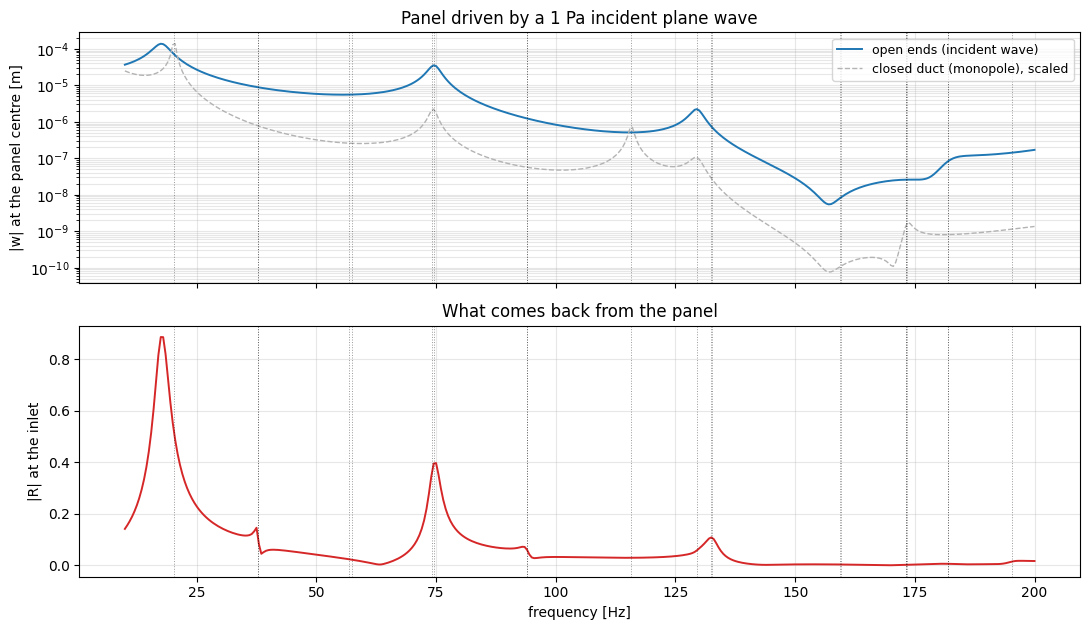

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True)

axes[0].semilogy(frequencies, np.abs(w_open), color="C0", lw=1.4,
                 label="open ends (incident wave)")
axes[0].semilogy(frequencies, np.abs(res_source["w"][dof])
                 / np.abs(res_source["w"][dof]).max()
                 * np.abs(w_open).max(), color="0.7", lw=1.0, ls="--",
                 label="closed duct (monopole), scaled")
axes[0].set(ylabel="|w| at the panel centre [m]",
            title="Panel driven by a 1 Pa incident plane wave")
axes[0].legend(loc="upper right", fontsize=9)

# Reflection seen at the inlet: total minus incident, over incident.
inlet_nodes = np.asarray(groups["inlet"]["nodes"], dtype=int) - 1
inlet_rows = np.array([np.where(idx_a_open == n)[0][0] for n in inlet_nodes])
p_inlet = res_wave["p"][inlet_rows].mean(axis=0)
axes[1].plot(frequencies, np.abs(p_inlet / P_INC - 1.0), color="C3", lw=1.4)
axes[1].set(xlabel="frequency [Hz]", ylabel="|R| at the inlet",
            title="What comes back from the panel")

for ax in axes:
    for k, f in enumerate(f_coupled[(f_coupled > F_MIN) & (f_coupled < F_MAX)]):
        ax.axvline(f, color="k", ls=":", lw=0.7, alpha=0.4,
                   label="closed-duct modes" if k == 0 else None)
    ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

Two things changed by opening the ends. The **air spring is gone**: the first
panel resonance drops back towards its in-vacuo value, because a sealed volume is
what stiffened it. And the peaks are **broader**: the panel now radiates into a
duct that never sends the energy back, which is damping — physical damping, on top
of the loss factor. The dotted lines are the closed-duct modes of section 5, kept
as a reference to show how far the open case has moved.

## 10. Watching the solution change with frequency

The sweep is a stack of complex fields, one per frequency. Two ways to walk
through it: a slider, when the notebook is live, and a movie, which survives being
saved.

In [17]:
plate_nodes0 = system["structural"]["nodes0"]
xs_p, ix_p = np.unique(np.round(nodes[plate_nodes0, 0], 6), return_inverse=True)
ys_p, iy_p = np.unique(np.round(nodes[plate_nodes0, 1], 6), return_inverse=True)
Xp, Yp = np.meshgrid(xs_p, ys_p)

# Pressure along the duct axis: nearest fluid node to the centre line, per x.
axis_x = np.unique(np.round(nodes[:, 0], 6))
centre_line = np.array([nodes[:, 1].mean(), nodes[:, 2].mean()])
axis_rows = []
for x in axis_x:
    near = np.where(np.abs(nodes[idx_a_open, 0] - x) < 1e-6)[0]
    d = np.linalg.norm(nodes[idx_a_open[near]][:, 1:] - centre_line, axis=1)
    axis_rows.append(near[np.argmin(d)])
axis_rows = np.array(axis_rows)

w_max = np.abs(res_wave["w"]).max()
p_max = np.abs(res_wave["p"]).max()


def solution_at(freq_index, fig=None):
    """Panel deflection and axial pressure at one frequency of the sweep."""
    field = structural_displacement_field(
        res_wave["w"][:, freq_index], res_wave["idx_s"], nodes.shape[0]
    )
    uz = np.zeros((ys_p.size, xs_p.size))
    uz[iy_p, ix_p] = np.real(field[plate_nodes0, 2])

    fig = fig or plt.figure(figsize=(11, 3.8))
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot_surface(Xp, Yp, uz, cmap="RdBu_r", vmin=-w_max, vmax=w_max,
                     linewidth=0.2, edgecolor="k")
    ax1.set(xlabel="x [m]", ylabel="y [m]", zlim=(-w_max, w_max),
            title=f"panel, Re(w) at {frequencies[freq_index]:.1f} Hz")
    ax1.set_zticklabels([])

    ax2 = fig.add_subplot(1, 2, 2)
    p_axis = res_wave["p"][axis_rows, freq_index]
    ax2.plot(axis_x, np.abs(p_axis), color="C3", lw=1.6, label="|p|")
    ax2.plot(axis_x, np.real(p_axis), color="0.5", lw=1.0, label="Re(p)")
    ax2.axvspan(1.0, 2.0, color="C0", alpha=0.12, label="panel")
    ax2.set(xlabel="x [m]", ylabel="p [Pa]", ylim=(-p_max, p_max),
            title="pressure on the duct axis")
    ax2.legend(loc="upper right", fontsize=8)
    ax2.grid(alpha=0.3)
    return fig


try:
    from ipywidgets import IntSlider, interact

    interact(
        lambda i: (solution_at(i), plt.show()),
        i=IntSlider(min=0, max=frequencies.size - 1,
                    step=1, value=i_peak, description="freq index"),
    )
except ImportError:
    print("ipywidgets not installed: use the static frames below.")

interactive(children=(IntSlider(value=15, description='freq index', max=380), Output()), _dom_classes=('widget…

The slider above is live in a running notebook. Saved to a file it keeps only its
last frame, so here are four frequencies side by side — off resonance, on the
first panel resonance, between, and on a duct-controlled peak.

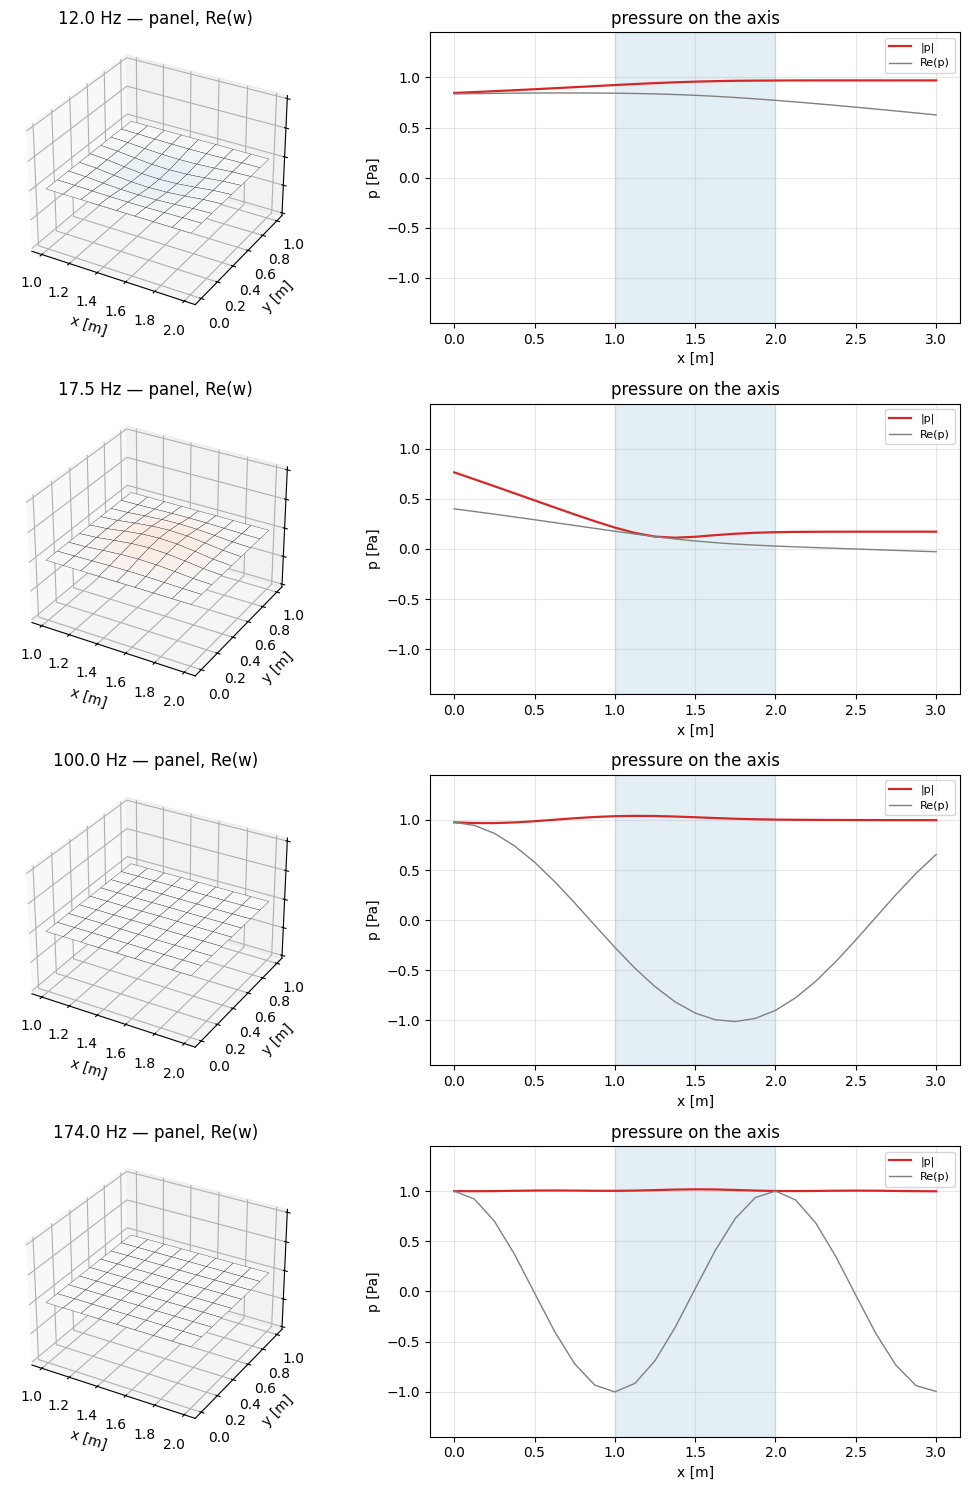

In [18]:
picks = [int(np.argmin(np.abs(frequencies - f)))
         for f in (12.0, frequencies[i_peak], 100.0, 174.0)]

fig = plt.figure(figsize=(11, 15))
for row, index in enumerate(picks):
    ax1 = fig.add_subplot(4, 2, 2 * row + 1, projection="3d")
    field = structural_displacement_field(
        res_wave["w"][:, index], res_wave["idx_s"], nodes.shape[0]
    )
    uz = np.zeros((ys_p.size, xs_p.size))
    uz[iy_p, ix_p] = np.real(field[plate_nodes0, 2])
    ax1.plot_surface(Xp, Yp, uz, cmap="RdBu_r", vmin=-w_max, vmax=w_max,
                     linewidth=0.2, edgecolor="k")
    ax1.set(zlim=(-w_max, w_max), xlabel="x [m]", ylabel="y [m]",
            title=f"{frequencies[index]:.1f} Hz — panel, Re(w)")
    ax1.set_zticklabels([])

    ax2 = fig.add_subplot(4, 2, 2 * row + 2)
    p_axis = res_wave["p"][axis_rows, index]
    ax2.plot(axis_x, np.abs(p_axis), color="C3", lw=1.6, label="|p|")
    ax2.plot(axis_x, np.real(p_axis), color="0.5", lw=1.0, label="Re(p)")
    ax2.axvspan(1.0, 2.0, color="C0", alpha=0.12)
    ax2.set(ylim=(-p_max, p_max), xlabel="x [m]", ylabel="p [Pa]",
            title="pressure on the axis")
    ax2.grid(alpha=0.3)
    ax2.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

Read them together: where the panel barely moves the axial pressure is flat at the
incident 1 Pa — the duct behaves as if the wall were hard. On a panel resonance
the deflection grows and the pressure develops a ripple: part of the wave is being
reflected and part absorbed by the panel, and the ripple is the interference
between the two.

Finally the same thing as a movie over the whole sweep, which is the honest way to
see a resonance sweep past — the frame rate is the sweep, not time.

Movie saved: duct_wave_sweep.mp4  (39 frames, 6 fps)
written duct_wave_sweep.mp4


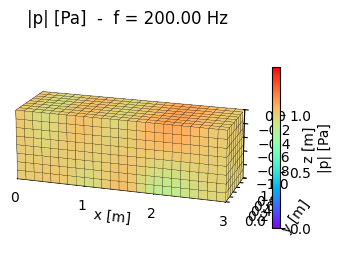

In [19]:
from pycafe.post_processing.post_processing_3d import (
    animate_pressure_3d, default_movie_extension,
)

step = 10                                   # one frame every 5 Hz
frames = np.arange(0, frequencies.size, step)
p_movie = expand_pressure(res_wave["p"][:, frames], res_wave["idx_a"],
                          nodes.shape[0])

ext = default_movie_extension()
movie = f"duct_wave_sweep{ext}"
animate_pressure_3d(
    nodes, elements, p_movie, frequencies[frames],
    mode="sweep", filename=movie, fps=6, elev=18, azim=-72,
    figsize=(7.5, 3.0), dpi=90,
)
print(f"written {movie}")

from IPython.display import Image, Video, display

display(Video(movie, embed=True) if ext == ".mp4" else Image(movie))

## What this workflow guarantees, and what it does not

**Guaranteed**, because the mesh is built and then checked:

* the model is in metres whatever unit the CAD used, and the check is printed;
* the mesh is hexahedral, so every element has a kernel;
* the panel is a patch of the wall, so the interface is conforming — the validator
  states it face by face;
* the element size resolves the requested band, with the dispersion error quoted.

**Not guaranteed**, and worth stating in any report built on this:

* the CAD must be box-shaped. A general shape would mesh tetrahedral, and the
  builder refuses it rather than producing a model pyCAFE cannot assemble;
* both ends of the duct are closed and rigid here. A duct that radiates needs an
  impedance on the end faces — the group is there, the condition is a one-line
  change (`AcousticBC().add_anechoic("x_max")`), but the numbers above are for a
  closed duct;
* the panel is modelled as flush and clamped. A real mounting has finite edge
  stiffness, which lowers the panel frequencies; `support="simply_supported"`
  brackets the other extreme.

**See also** — `vibroacoustic_plate_cavity.ipynb` for the same physics on a
parametric cavity, with the modal expansion and CMS reduction compared in detail.